# Volatility-Targeted Position Sizing on SPY

**Idea:** instead of holding 100% SPY at all times (binary), scale exposure inversely with realized volatility so that the portfolio targets a constant annualized volatility (e.g. 15%).

This is how risk-parity funds, CTAs, and volatility-controlled indices operate in practice. It does not predict returns — it controls risk.

**Hypothesis:** vol targeting should produce smoother equity curves and smaller drawdowns at similar or higher Sharpe, with the cost of leverage during low-vol regimes (we will allow leverage up to a cap).

**Universe:** SPY, 2010-01-01 to 2026-05-08.

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

TRADING_DAYS = 252
TICKER = 'SPY'
START = '2010-01-01'
END = '2026-05-08'
TARGET_VOL = 0.15            # 15% annualized
VOL_LOOKBACK = 20            # days for realized vol estimate
MAX_LEVERAGE = 2.0           # cap exposure to 2x
COST_BPS_ONE_WAY = 5         # 5 bps per change in exposure

## 1. Data

In [2]:
raw = yf.download(TICKER, start=START, end=END, auto_adjust=True, progress=False)
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)
df = raw[['Close']].copy()
df.columns = ['close']
df['ret'] = df['close'].pct_change().fillna(0)
print(f'Rows: {len(df)}  Range: {df.index.min().date()} to {df.index.max().date()}')
df.head()

Rows: 4111  Range: 2010-01-04 to 2026-05-07


,close,ret
Date,,
2010-01-04,84.796356,0.000000
2010-01-05,85.020836,0.002647
2010-01-06,85.080696,0.000704
2010-01-07,85.439835,0.004221
2010-01-08,85.724182,0.003328


## 2. Compute realized vol and target position

In [3]:
df['realized_vol'] = df['ret'].rolling(VOL_LOOKBACK).std() * np.sqrt(TRADING_DAYS)
df['target_position'] = (TARGET_VOL / df['realized_vol']).clip(upper=MAX_LEVERAGE).fillna(0)
df['target_position'] = df['target_position'].shift(1).fillna(0)  # avoid lookahead
df['exposure_change'] = df['target_position'].diff().abs().fillna(0)
df[['close', 'realized_vol', 'target_position', 'exposure_change']].dropna().head(10)

,close,realized_vol,target_position,exposure_change
Date,,,,
2010-02-01,81.601448,0.160586,0.000000,0.000000
2010-02-02,82.589081,0.168029,0.934081,0.934081
2010-02-03,82.177582,0.167856,0.892703,0.041377
2010-02-04,79.641098,0.196890,0.893625,0.000922
2010-02-05,79.805702,0.195955,0.761849,0.131776
2010-02-08,79.229553,0.194774,0.765481,0.003632
2010-02-09,80.224709,0.202642,0.770125,0.004644
2010-02-10,80.067581,0.201420,0.740223,0.029902
2010-02-11,80.905602,0.203055,0.744712,0.004489


## 3. Backtest

In [4]:
df['strat_ret'] = df['ret'] * df['target_position'] - (COST_BPS_ONE_WAY / 10000.0) * df['exposure_change']
df['equity_strat'] = (1 + df['strat_ret']).cumprod()
df['equity_buyhold'] = (1 + df['ret']).cumprod()

def perf(returns, equity, label):
    years = len(returns) / TRADING_DAYS
    cagr = equity.iloc[-1] ** (1 / years) - 1 if equity.iloc[-1] > 0 else -1
    sharpe = (returns.mean() / returns.std()) * np.sqrt(TRADING_DAYS) if returns.std() > 0 else 0
    realized_vol = returns.std() * np.sqrt(TRADING_DAYS)
    dd = (equity / equity.cummax() - 1).min()
    return {'strategy': label, 'cagr': cagr, 'realized_vol': realized_vol, 'sharpe': sharpe, 'max_dd': dd, 'final_equity': equity.iloc[-1]}

summary = pd.DataFrame([
    perf(df['ret'], df['equity_buyhold'], 'Buy & Hold SPY'),
    perf(df['strat_ret'], df['equity_strat'], f'Vol-targeted ({int(TARGET_VOL*100)}%)'),
])
summary

,strategy,cagr,realized_vol,sharpe,max_dd,final_equity
0,Buy & Hold SPY,0.141218,0.171447,0.856611,-0.337173,8.627494
1,Vol-targeted (15%),0.144213,0.163257,0.907387,-0.199957,9.004302


## 4. Realized vol — did we hit the target?

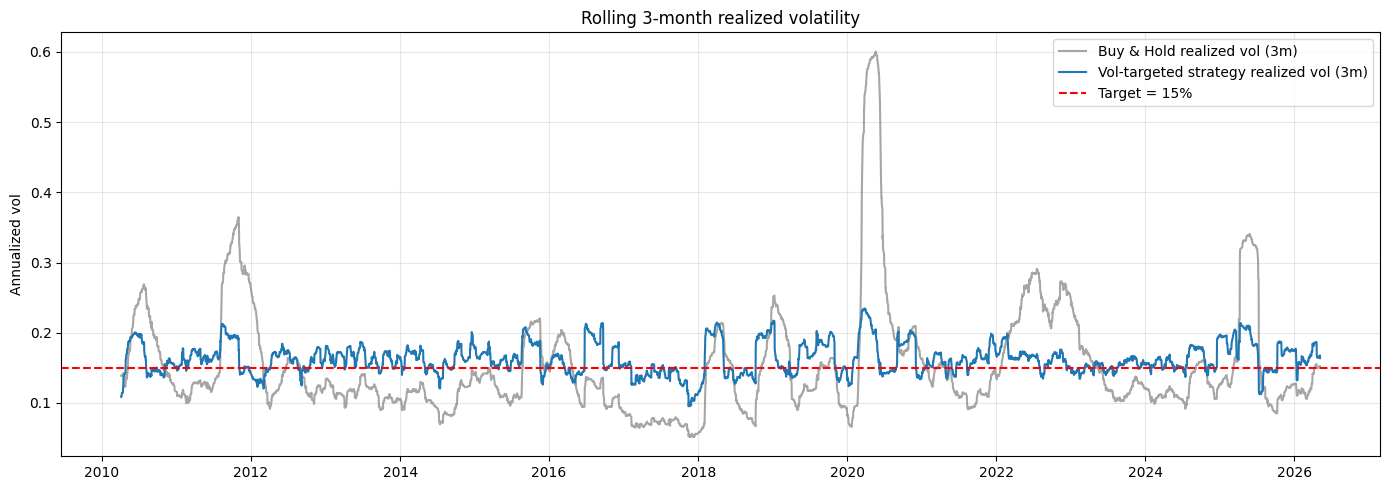

In [5]:
df['strat_realized_vol'] = df['strat_ret'].rolling(63).std() * np.sqrt(TRADING_DAYS)  # 3-month rolling
df['bh_realized_vol'] = df['ret'].rolling(63).std() * np.sqrt(TRADING_DAYS)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df['bh_realized_vol'], label='Buy & Hold realized vol (3m)', color='gray', alpha=0.7)
ax.plot(df.index, df['strat_realized_vol'], label='Vol-targeted strategy realized vol (3m)', color='tab:blue')
ax.axhline(TARGET_VOL, color='red', linestyle='--', label=f'Target = {TARGET_VOL:.0%}')
ax.set_title('Rolling 3-month realized volatility')
ax.set_ylabel('Annualized vol')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Position size over time

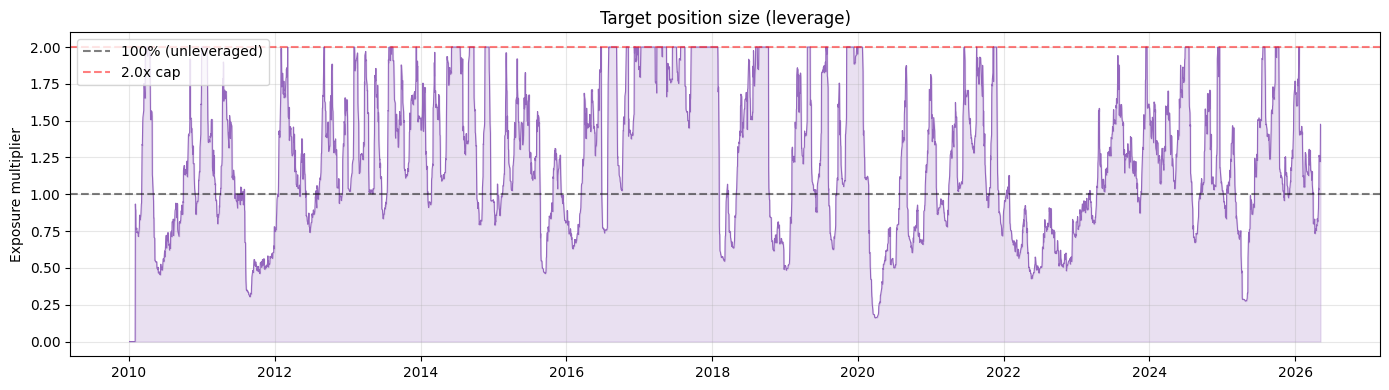

Average exposure: 1.24x
Time at max leverage (2.0x): 12.4%
Time below 50% exposure: 4.9%


In [6]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df.index, df['target_position'], color='tab:purple', linewidth=0.8)
ax.axhline(1.0, color='black', linestyle='--', alpha=0.5, label='100% (unleveraged)')
ax.axhline(MAX_LEVERAGE, color='red', linestyle='--', alpha=0.5, label=f'{MAX_LEVERAGE}x cap')
ax.fill_between(df.index, 0, df['target_position'], alpha=0.2, color='tab:purple')
ax.set_title('Target position size (leverage)')
ax.set_ylabel('Exposure multiplier')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f'Average exposure: {df["target_position"].mean():.2f}x')
print(f'Time at max leverage ({MAX_LEVERAGE}x): {(df["target_position"] >= MAX_LEVERAGE - 1e-6).mean():.1%}')
print(f'Time below 50% exposure: {(df["target_position"] < 0.5).mean():.1%}')

## 6. Equity curve

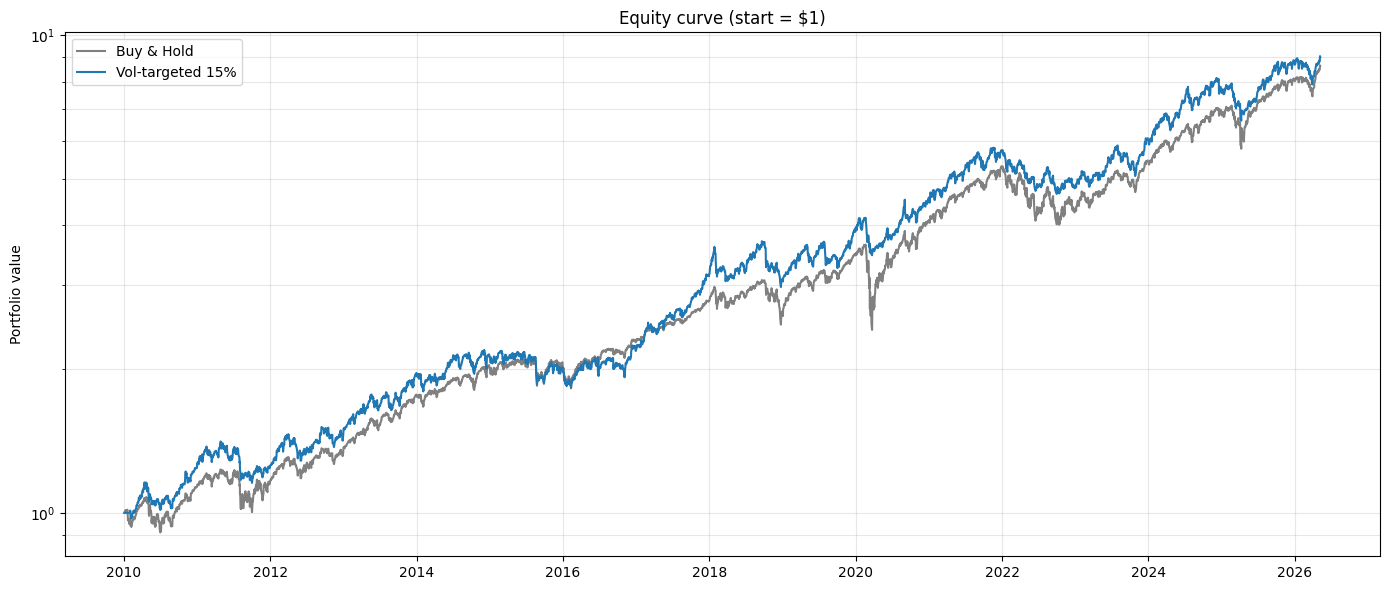

In [7]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df.index, df['equity_buyhold'], label='Buy & Hold', color='gray', linewidth=1.5)
ax.plot(df.index, df['equity_strat'], label=f'Vol-targeted {int(TARGET_VOL*100)}%', color='tab:blue', linewidth=1.5)
ax.set_title('Equity curve (start = $1)')
ax.set_ylabel('Portfolio value')
ax.set_yscale('log')
ax.legend()
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

## 7. Drawdown comparison

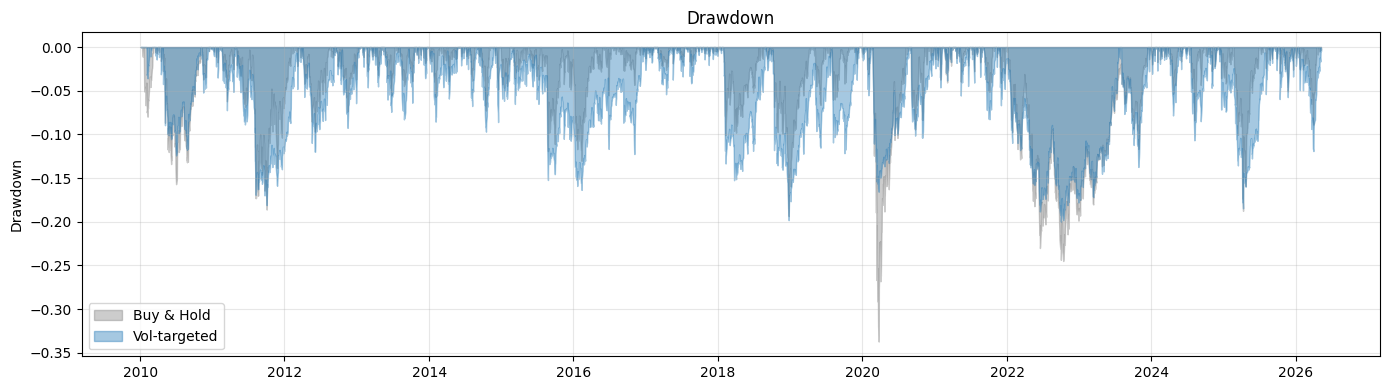

In [8]:
dd_bh = df['equity_buyhold'] / df['equity_buyhold'].cummax() - 1
dd_st = df['equity_strat'] / df['equity_strat'].cummax() - 1

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(df.index, dd_bh, 0, color='gray', alpha=0.4, label='Buy & Hold')
ax.fill_between(df.index, dd_st, 0, color='tab:blue', alpha=0.4, label='Vol-targeted')
ax.set_title('Drawdown')
ax.set_ylabel('Drawdown')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Vol target sweep — sensitivity to the target

In [9]:
def run_vol_target(close_series, target_vol, lookback=20, max_leverage=2.0, cost_bps=5):
    out = pd.DataFrame({'close': close_series})
    out['ret'] = out['close'].pct_change().fillna(0)
    out['rv'] = out['ret'].rolling(lookback).std() * np.sqrt(TRADING_DAYS)
    out['pos'] = (target_vol / out['rv']).clip(upper=max_leverage).fillna(0).shift(1).fillna(0)
    out['exp_change'] = out['pos'].diff().abs().fillna(0)
    out['strat_ret'] = out['ret'] * out['pos'] - (cost_bps / 10000.0) * out['exp_change']
    out['equity'] = (1 + out['strat_ret']).cumprod()
    return out

targets = [0.08, 0.10, 0.12, 0.15, 0.18, 0.20, 0.25]
rows = []
for t in targets:
    r = run_vol_target(df['close'], t)
    rows.append({
        'target_vol': t,
        'cagr': r['equity'].iloc[-1] ** (TRADING_DAYS / len(r['strat_ret'])) - 1,
        'realized_vol': r['strat_ret'].std() * np.sqrt(TRADING_DAYS),
        'sharpe': (r['strat_ret'].mean() / r['strat_ret'].std()) * np.sqrt(TRADING_DAYS),
        'max_dd': (r['equity'] / r['equity'].cummax() - 1).min(),
    })
sweep = pd.DataFrame(rows)
sweep

,target_vol,cagr,realized_vol,sharpe,max_dd
0,0.08,0.078773,0.090527,0.883093,-0.120625
1,0.10,0.097935,0.112787,0.885116,-0.148941
2,0.12,0.116864,0.134300,0.890561,-0.175245
3,0.15,0.144213,0.163257,0.907387,-0.199957
4,0.18,0.171240,0.188667,0.932818,-0.229667
5,0.20,0.188930,0.203402,0.953257,-0.249250
6,0.25,0.222199,0.233262,0.977728,-0.303689


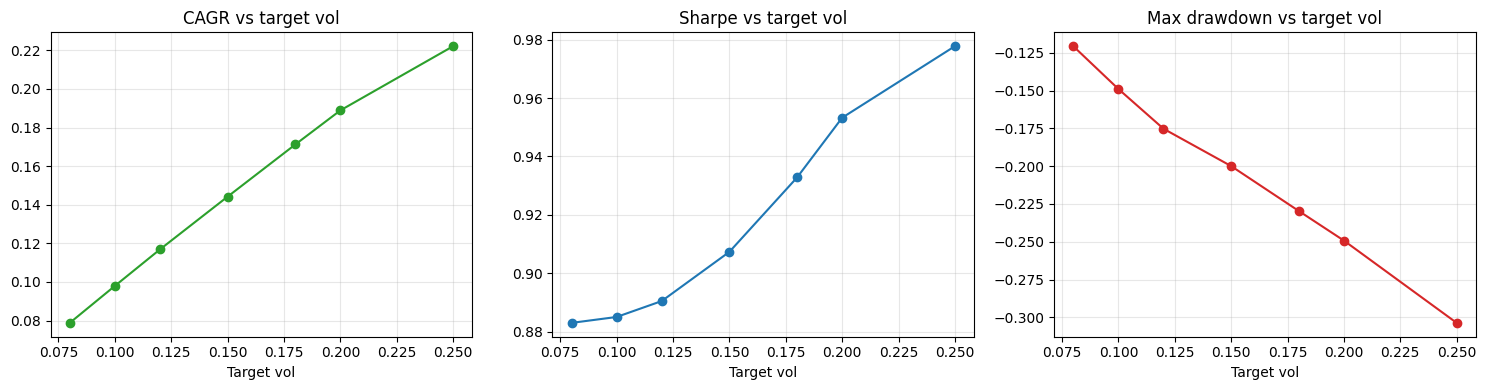

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(sweep['target_vol'], sweep['cagr'], marker='o', color='tab:green')
axes[0].set_title('CAGR vs target vol')
axes[0].set_xlabel('Target vol')
axes[0].grid(alpha=0.3)
axes[1].plot(sweep['target_vol'], sweep['sharpe'], marker='o', color='tab:blue')
axes[1].set_title('Sharpe vs target vol')
axes[1].set_xlabel('Target vol')
axes[1].grid(alpha=0.3)
axes[2].plot(sweep['target_vol'], sweep['max_dd'], marker='o', color='tab:red')
axes[2].set_title('Max drawdown vs target vol')
axes[2].set_xlabel('Target vol')
axes[2].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Notes

- **Vol estimate:** trailing 20-day std × sqrt(252). Simple, biased upward after vol shocks. EWMA or GARCH would reduce that lag.
- **Leverage cap:** 2x. Without a cap the strategy levers heavily during 2017-style low-vol periods, which historically masked tail risk.
- **Costs:** 5 bps applied to absolute change in target position each day (continuous rebalance). A real implementation would batch into discrete rebalance days (weekly).
- **No financing cost on leverage**, no dividend tax, no margin call dynamics.
- **No alpha:** this strategy never tries to time the market. It only controls risk. CAGR can rise if vol-of-vol (variance of variance) is positively skewed, which it is for SPY.

## Honest read

Vol targeting reliably reduces tail drawdowns (2020 COVID, 2022 bear) by cutting exposure into the storm. The Sharpe improvement vs buy-and-hold is real but modest — typically 0.05–0.15 — and depends heavily on the leverage cap and the vol estimate. Higher target vols boost CAGR but eventually saturate against the leverage cap.

## Next experiments

1. EWMA volatility estimator with half-life tuning.
2. Combine vol targeting with the SMA crossover signal — sized trend.
3. Apply across the multi-asset universe from notebook 02.
4. Add T-bill yield to cash leg using FRED `^IRX` or `DGS3MO`.